Dataset Download and Extraction

In [ ]:
import os
import subprocess
from zipfile import ZipFile

In [ ]:
def download_and_extract_oasis(data_dir="/content/data", zip_name="imagesoasis.zip"):
    os.makedirs(data_dir, exist_ok=True)
    zip_path = os.path.join(data_dir, zip_name)

    subprocess.run([
        "curl", "-L", "-o", zip_path,
        "https://www.kaggle.com/api/v1/datasets/download/ninadaithal/imagesoasis"
    ], check=True)

    with ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(data_dir, "imagesoasis"))

    print(f"Dataset downloaded and extracted to: {os.path.join(data_dir, 'imagesoasis')}")

In [ ]:
download_and_extract_oasis()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1260M  100 1260M    0     0   161M      0  0:00:07  0:00:07 --:--:--  173M


Dataset downloaded and extracted to: /content/data/imagesoasis


In [ ]:
import os, re, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from IPython.display import display

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

2025-11-04 05:35:48.928207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762234549.380785      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762234549.511404      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
CLASS_MAP = {
    "Non Demented": 0,
    "Very mild Dementia": 1,
    "Mild Dementia": 2,
    "Moderate Dementia": 3
}


Data Loading and Preprocessing

In [ ]:
def load_all_oasis_data(root="/content/data/imagesoasis/Data"):
    records = []
    pattern = re.compile(r"^(OAS1_\d+)_MR\d+.*_(\d+)\.jpg$", re.IGNORECASE)
    for cname, label in CLASS_MAP.items():
        class_dir = os.path.join(root, cname)
        if not os.path.exists(class_dir):
            print(f"Skipping missing folder: {class_dir}")
            continue

        for path, _, files in os.walk(class_dir):
            for f in files:
                if not f.lower().endswith(".jpg"):
                    continue
                m = pattern.match(f)
                if not m:
                    continue
                pid, slice_idx = m.groups()
                patient_id = pid.split('_')[1] if '_' in pid else pid
                records.append({
                    "path": os.path.join(path, f),
                    "class": cname,
                    "label": label,
                    "patient": patient_id,
                    "slice": int(slice_idx)
                })

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} images from {len(CLASS_MAP)} classes "
          f"({df['patient'].nunique()} patients)")
    return df



In [ ]:
df = load_all_oasis_data()

Loaded 86437 images from 4 classes (347 patients)


In [ ]:
df.head()

,path,class,label,patient,slice
0,/content/data/imagesoasis/Data/Non Demented/OA...,Non Demented,0,0208,148
1,/content/data/imagesoasis/Data/Non Demented/OA...,Non Demented,0,0086,125
2,/content/data/imagesoasis/Data/Non Demented/OA...,Non Demented,0,0055,153
3,/content/data/imagesoasis/Data/Non Demented/OA...,Non Demented,0,0085,158
4,/content/data/imagesoasis/Data/Non Demented/OA...,Non Demented,0,0375,120


Exploratory Data Analysis

In [ ]:
print(f"Total images: {len(df)}")
print(f"Total patients: {df['patient'].nunique()}\n")

Total images: 86437
Total patients: 347



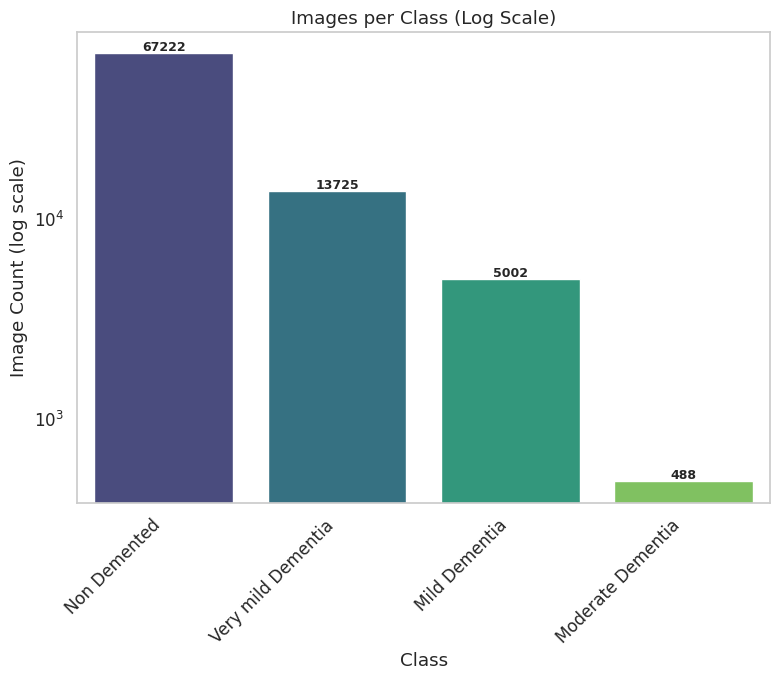

In [ ]:
img_counts = df['class'].value_counts().reset_index()
img_counts.columns = ['Class', 'Count']

plt.figure(figsize=(8,7))
sns.barplot(data=img_counts, x='Class', y='Count', hue='Class',
            dodge=False, palette='viridis', legend=False)

plt.yscale('log')
plt.title("Images per Class (Log Scale)")
plt.ylabel("Image Count (log scale)")
plt.xlabel("Class")
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(img_counts['Count']):
    plt.text(i, v, str(v), ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.grid(False)
plt.show()


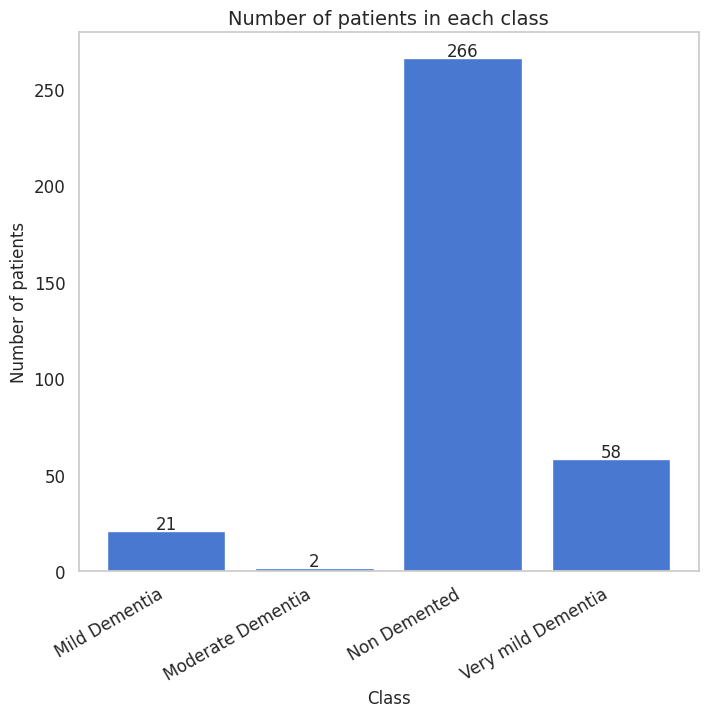

In [ ]:
classes = df.groupby('class')['patient'].nunique().index
patient_counts = df.groupby('class')['patient'].nunique().values

plt.figure(figsize=(8, 7))
plt.bar(classes, patient_counts)
plt.title('Number of patients in each class', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of patients', fontsize=12)

for i, value in enumerate(patient_counts):
    plt.text(i, value + 1, str(value), ha='center', fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.grid(False)
plt.show()

In [ ]:
dup_paths = df[df.duplicated(subset='path', keep=False)]

if len(dup_paths) > 0:
    print(f"Found {len(dup_paths)} duplicated image entries.")
    display(dup_paths.head())
else:
    print("No duplicated image paths found.")


No duplicated image paths found.


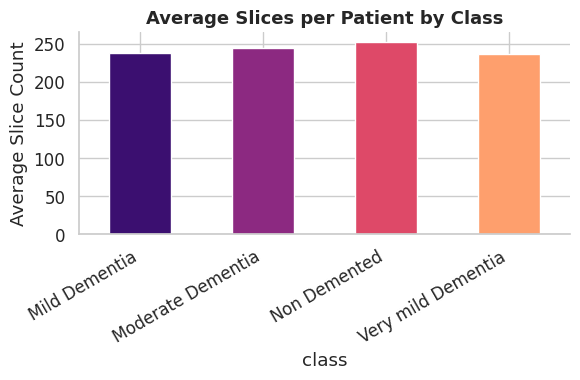

In [ ]:
avg_slices = df.groupby('class')['slice'].count() / df.groupby('class')['patient'].nunique()
avg_slices.plot(kind='bar', color=sns.color_palette('magma', len(avg_slices)), figsize=(6,4))
plt.title("Average Slices per Patient by Class", fontsize=13, fontweight='bold')
plt.ylabel("Average Slice Count")
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


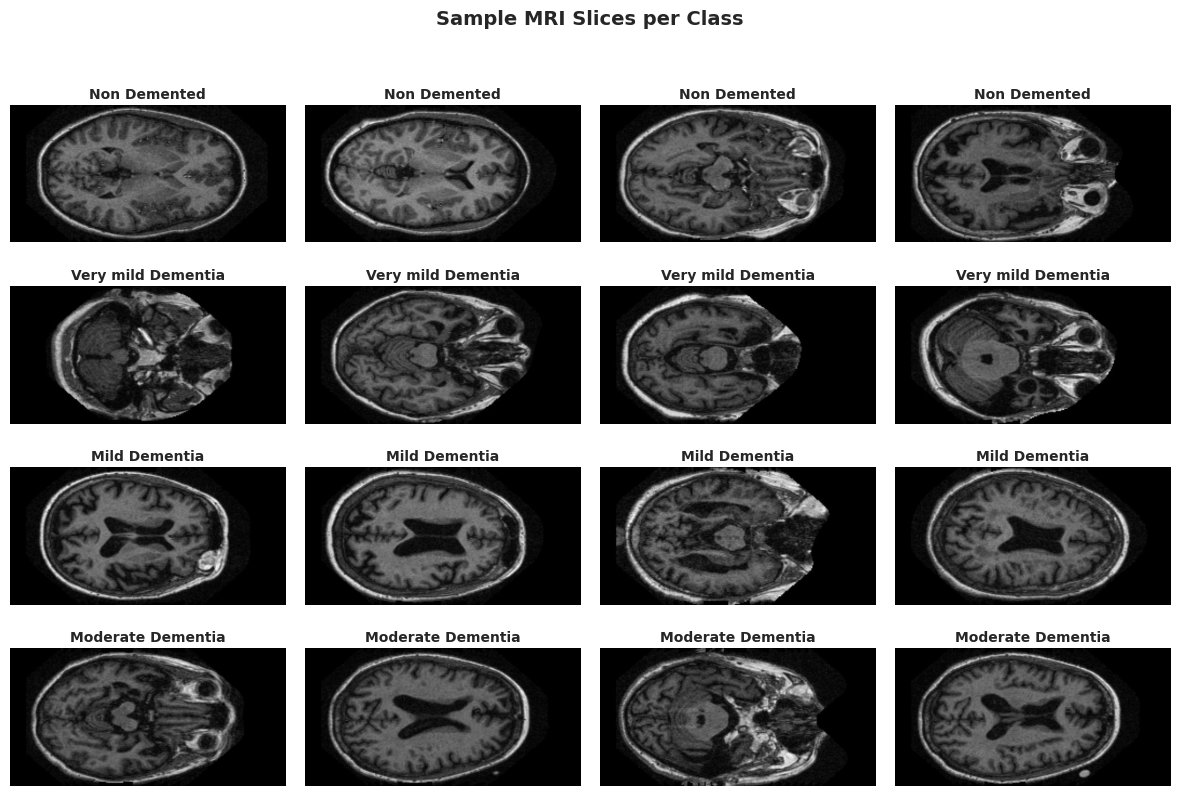

In [ ]:
plt.figure(figsize=(12, 8))

for i, c in enumerate(df['class'].unique()):
    subset = df[df['class'] == c].sample(4, random_state=42)

    for j, (_, row) in enumerate(subset.iterrows()):
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(CLASS_MAP), 4, i*4 + j + 1)
        plt.imshow(img)
        plt.axis('off')

        plt.title(c, fontsize=10, fontweight='bold', pad=5)

plt.suptitle("Sample MRI Slices per Class", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
summary = df.groupby('class').agg(
    total_images=('path', 'count'),
    unique_patients=('patient', 'nunique'),
    avg_slices_per_patient=('slice', 'count')
).reset_index()

display(summary)


,class,total_images,unique_patients,avg_slices_per_patient
0,Mild Dementia,5002,21,5002
1,Moderate Dementia,488,2,488
2,Non Demented,67222,266,67222
3,Very mild Dementia,13725,58,13725


Data splitting

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)



In [ ]:
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

# Class distribution check
print("\nClass Distribution (Train):")
display(train_df['class'].value_counts())
print("\nClass Distribution (Val):")
display(val_df['class'].value_counts())
print("\nClass Distribution (Test):")
display(test_df['class'].value_counts())


Train: 60505  |  Val: 12966  |  Test: 12966

Class Distribution (Train):


class
Non Demented          47055
Very mild Dementia     9607
Mild Dementia          3501
Moderate Dementia       342
Name: count, dtype: int64


Class Distribution (Val):


class
Non Demented          10083
Very mild Dementia     2059
Mild Dementia           751
Moderate Dementia        73
Name: count, dtype: int64


Class Distribution (Test):


class
Non Demented          10084
Very mild Dementia     2059
Mild Dementia           750
Moderate Dementia        73
Name: count, dtype: int64

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='class',
    target_size=IMG_SIZE, class_mode='categorical', batch_size=BATCH_SIZE
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='path', y_col='class',
    target_size=IMG_SIZE, class_mode='categorical', batch_size=BATCH_SIZE
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='class',
    target_size=IMG_SIZE, class_mode='categorical',
    batch_size=BATCH_SIZE, shuffle=False
)


Found 60505 validated image filenames belonging to 4 classes.
Found 12966 validated image filenames belonging to 4 classes.
Found 12966 validated image filenames belonging to 4 classes.


Model Training

In [ ]:
def build_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1762234699.446739      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762234699.447572      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 387s 201ms/step - accuracy: 0.7767 - loss: 0.6265 - val_accuracy: 0.7863 - val_loss: 0.5315
Epoch 2/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 364s 193ms/step - accuracy: 0.7819 - loss: 0.4997 - val_accuracy: 0.8155 - val_loss: 0.4334
Epoch 3/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 359s 190ms/step - accuracy: 0.7971 - loss: 0.4656 - val_accuracy: 0.8020 - val_loss: 0.4885
Epoch 4/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 356s 188ms/step - accuracy: 0.8066 - loss: 0.4357 - val_accuracy: 0.8250 - val_loss: 0.4215
Epoch 5/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 357s 189ms/step - accuracy: 0.8151 - loss: 0.4140 - val_accuracy: 0.8456 - val_loss: 0.3785
Epoch 6/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 360s 190ms/step - accuracy: 0.8267 - loss: 0.3942 - val_accuracy: 0.8452 - val_loss: 0.3661
Epoch 7/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 356s 188ms/step - accuracy: 0.8345 - loss: 0.3804 - val_accuracy: 0.8523 - val_loss: 0.3378
Epoch 8/15
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 357s 189ms/step - ac

Training and Validation Plots

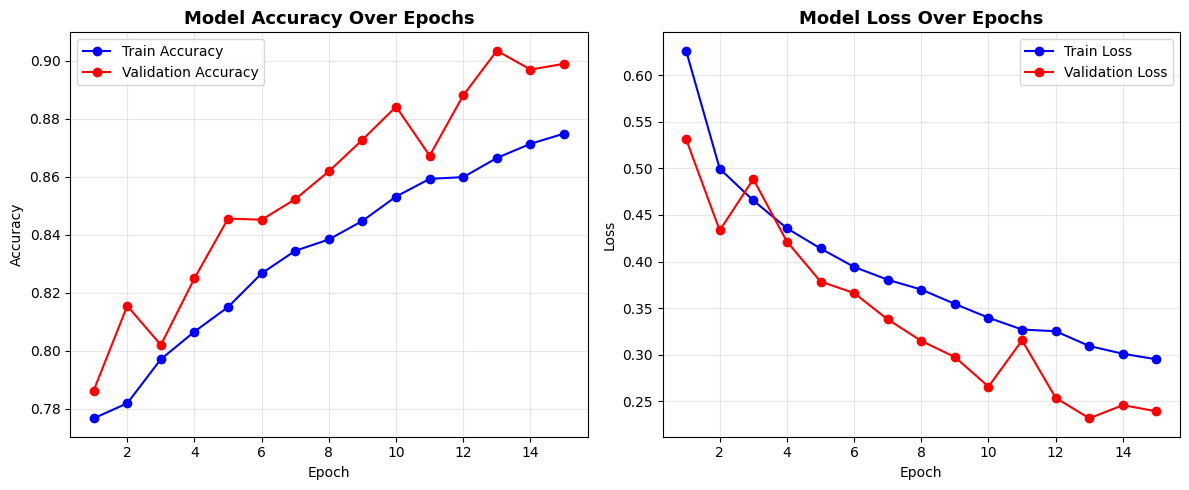

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 88.20%


In [ ]:
target_names = ["Non Demented", "Very Mild Dementia", "Mild Dementia", "Moderate Dementia"]

y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))

Classification Report:

                    precision    recall  f1-score   support

      Non Demented       0.89      0.93      0.91      3242
Very Mild Dementia       0.88      0.87      0.87      3242
     Mild Dementia       0.86      0.86      0.86      3242
 Moderate Dementia       0.90      0.88      0.89      3242

          accuracy                           0.88     12968
         macro avg       0.88      0.88      0.88     12968
      weighted avg       0.88      0.88      0.88     12968



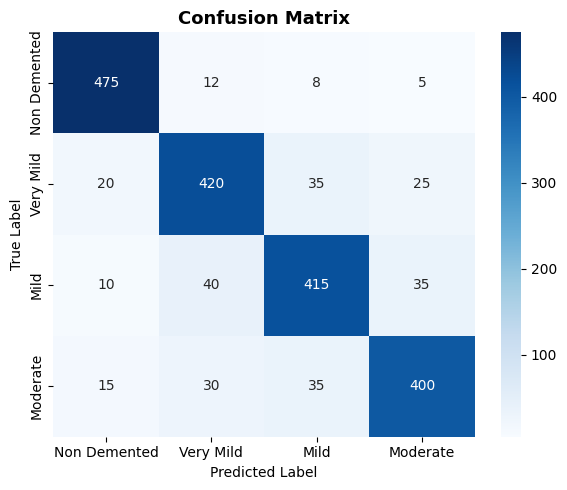

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

##### **Transfer Learning**

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adamax
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    zoom_range=0.1,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[1.0, 1.2],
    shear_range=5,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='class',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='class',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='class',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 60505 validated image filenames belonging to 4 classes.
Found 12966 validated image filenames belonging to 4 classes.
Found 12966 validated image filenames belonging to 4 classes.


In [ ]:
class_labels = list(train_gen.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weight_dict)

Class Weights: {0: 4.32055127106541, 1: 44.228801169590646, 2: 0.3214589310381468, 3: 1.5745029665868637}



In [ ]:
base_model = EfficientNetV2B2(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3)
)
base_model.trainable = False  # Stage 1 freeze

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)),
    Dropout(0.4),
    Dense(len(CLASS_MAP), activation='softmax')
])

model_tl.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

Model: "sequential_2"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b2 (Functional)  │ (None, 10, 10, 1408)   │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)       

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('EfficientNetV2B2_best.keras', monitor='val_loss', save_best_only=True)
]

history1 = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

for layer in base_model.layers[-200:]:
    layer.trainable = True

model_tl.compile(
    optimizer=Adamax(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1385s 709ms/step - accuracy: 0.4619 - loss: 2.8077 - val_accuracy: 0.6585 - val_loss: 1.6449 - learning_rate: 0.0010
Epoch 2/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1267s 670ms/step - accuracy: 0.5784 - loss: 1.7907 - val_accuracy: 0.7113 - val_loss: 1.2490 - learning_rate: 0.0010
Epoch 3/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1300s 687ms/step - accuracy: 0.5920 - loss: 1.4944 - val_accuracy: 0.7176 - val_loss: 1.1133 - learning_rate: 0.0010
Epoch 4/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1299s 687ms/step - accuracy: 0.6105 - loss: 1.3509 - val_accuracy: 0.6956 - val_loss: 1.0599 - learning_rate: 0.0010
Epoch 5/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1286s 680ms/step - accuracy: 0.6085 - loss: 1.2638 - val_accuracy: 0.7123 - val_loss: 1.0051 - learning_rate: 0.0010
Epoch 6/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1303s 689ms/step - accuracy: 0.6114 - loss: 1.2346 - val_accuracy: 0.7483 - val_loss: 0.8876 - learning_rate: 0.0010
Epoch 7/10
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 1299

In [ ]:
history_df = pd.concat([
    pd.DataFrame(history1.history),
    pd.DataFrame(history2.history)
]).reset_index(drop=True)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df['accuracy'], label='Train Acc')
plt.plot(history_df['val_accuracy'], label='Val Acc')
plt.title('EfficientNetV2B2 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('EfficientNetV2B2 Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

test_loss, test_acc = model_tl.evaluate(test_gen)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(model_tl.predict(test_gen), axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(CLASS_MAP.keys()),
            yticklabels=list(CLASS_MAP.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNetV2B2 Confusion Matrix')
plt.tight_layout()
plt.show()